# Autoregressive Chemulator vs mini-chem vs VULCAN

Companion to `minichem_compare.ipynb`. The main notebook runs Chemulator in **one-shot
mode** (every t[i] predicted directly from y[0]) — by construction, errors don't compound.
Here we step Chemulator through a time grid, **feeding each prediction back as the next
step's input**, so both surrogates accumulate error the way they would inside a GCM.

Two grids:

1. **VULCAN-matched grid (99 steps).** Uses `t_vec[i] - t_vec[i-1]` so Chemulator and
   mini-chem step at the same instants as the VULCAN reference.
2. **Dense grid (1000 steps).** Log-spaced from t≈0.02 s to 1e8 s, smallest dt ≈ 4.5e-4 s,
   ~1.5× the trained `DT_MIN`. Both methods step at the finer grid; VULCAN truth is plotted
   from its own 100-point trajectory.

All step sizes lie inside the model's trained dt range [≈3e-4, 1e8] s, so the emulator
isn't extrapolating.


In [1]:
import json
import subprocess
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.lines import Line2D

# Resolve repo root whether launched from testing/ or Chemulator/
_cwd = Path().resolve()
REPO          = _cwd if (_cwd / "models" / "final_model").exists() else _cwd.parent
TESTING_DIR   = REPO / "testing"
MODEL_DIR     = REPO / "models" / "final_model"
SHARD         = REPO / "data" / "processed" / "test" / "shard_test_mix_r2_200015.npz"
MINI_CHEM_DIR = REPO.parent / "mini_chem"
MINI_CHEM_SRC = MINI_CHEM_DIR / "src_mini_chem_dlsode"
MINI_CHEM_BIN = MINI_CHEM_DIR / "mini_chem_dlsode"
MINI_CHEM_NML = MINI_CHEM_DIR / "mini_chem.nml"
MINI_CHEM_OUT = MINI_CHEM_DIR / "outputs_dlsode" / "dlsode.txt"

try:
    plt.style.use(str(TESTING_DIR / "science.mplstyle"))
except OSError:
    warnings.warn("science.mplstyle not found; using matplotlib defaults.")

ep         = torch.export.load(MODEL_DIR / "physical_model_k1_cpu.pt2")
chem_model = ep.module()

meta    = json.loads((MODEL_DIR / "physical_model_metadata.json").read_text())
SPECIES = meta["species_order"]
NAMES   = [s.removesuffix("_evolution") for s in SPECIES]
N_SP    = len(SPECIES)
DT_MIN  = meta["dt_bounds_sec"]["min"]
DT_MAX  = meta["dt_bounds_sec"]["max"]

d     = np.load(SHARD, allow_pickle=False)
y_mat = d["y_mat"].astype(np.float32)
g_mat = d["globals"].astype(np.float32)
t_vec = d["t_vec"].astype(np.float32)
N_TRAJ, N_TIME, _ = y_mat.shape
TINY  = 1e-35

# Stored pressure is dyn/cm^2 (VULCAN cgs), not Pa: the shard values span
# 1 -> 1e10, i.e. 1e-6 -> 1e4 bar.  mini-chem's namelist P_in is in Pa
# (mini_ch_i_dlsode.f90: P_cgs = P_in * 10.0_dp).  Convert once here and use
# P_Pa_all everywhere a pressure is passed to mini-chem, filtered on, or
# printed.  The emulator is fed g_mat unchanged: it was trained on the stored
# representation.
BARYE_TO_PA = 0.1
P_Pa_all = BARYE_TO_PA * g_mat[:, 0].astype(np.float64)


print(f"Loaded {N_TRAJ:,} test trajectories x {N_TIME} timesteps x {N_SP} species")
print(f"Trained dt range : [{DT_MIN:.3e}, {DT_MAX:.3e}] s")
print(f"VULCAN t_vec dt  : [{np.diff(t_vec).min():.3e}, {np.diff(t_vec).max():.3e}] s")


Loaded 32,624 test trajectories x 100 timesteps x 12 species
Trained dt range : [2.949e-04, 1.000e+08] s
VULCAN t_vec dt  : [2.949e-04, 2.278e+07] s


In [2]:
# mini-chem NCHO output order: OH H2 H2O H CO CO2 O CH4 C2H2 NH3 N2 HCN He
CHEM_TO_MINI = [8, 7, 5, 4, 2, 1, 11, 3, 10, 9, 0, 6]

def chem_to_mini_vmr(vmr_chem: np.ndarray) -> np.ndarray:
    vmr_mini = np.zeros(13)
    vmr_mini[CHEM_TO_MINI] = vmr_chem
    return vmr_mini

def mini_to_chem_vmr(vmr_mini: np.ndarray) -> np.ndarray:
    return np.array(vmr_mini[:12])[CHEM_TO_MINI]


In [3]:
def build_minichem() -> None:
    if MINI_CHEM_BIN.exists():
        print(f"mini-chem binary already present: {MINI_CHEM_BIN}")
        return
    print("Compiling mini-chem (dlsode) ...")
    result = subprocess.run(
        ["make"], cwd=str(MINI_CHEM_SRC), capture_output=True, text=True,
    )
    if result.returncode != 0:
        print("STDOUT:", result.stdout[-2000:])
        print("STDERR:", result.stderr[-2000:])
        raise RuntimeError("make failed - check gfortran installation.")
    print("Compiled successfully.")

build_minichem()


mini-chem binary already present: /Users/imalsky/Desktop/Emulators/Chemulator_Project/mini_chem/mini_chem_dlsode


In [4]:
def _write_nml(T_K: float, P_Pa: float, vmr_mini: np.ndarray, t_step: float) -> None:
    vmr_str = ", ".join(f"{max(float(v), 0.0):.10e}" for v in vmr_mini)
    MINI_CHEM_NML.write_text(
        "&mini_chem\n"
        f"network = 'NCHO'\n"
        f"T_in = {T_K:.6f}\n"
        f"P_in = {P_Pa:.10e}\n"
        f"t_step = {t_step:.10e}\n"
        "n_step = 1\n"
        "n_sp = 13\n"
        "data_file = 'chem_data/mini_chem_data_NCHO.txt'\n"
        "sp_file = 'chem_data/mini_chem_sp_NCHO.txt'\n"
        "net_dir = 'chem_data/1x/'\n"
        "met = '1x'\n"
        "/\n"
        "\n"
        "&mini_chem_VMR\n"
        "CE_IC = .False.\n"
        "IC_file = 'chem_data/IC/mini_chem_IC_FastChem_1x.txt'\n"
        f"VMR_IC = {vmr_str}\n"
        "/\n"
    )


def _run_one_step(T_K: float, P_Pa: float, vmr_chem: np.ndarray, dt: float) -> np.ndarray:
    vmr_mini = chem_to_mini_vmr(np.clip(vmr_chem, 0.0, None))
    _write_nml(T_K, P_Pa, vmr_mini, t_step=dt)
    result = subprocess.run(
        [str(MINI_CHEM_BIN)], cwd=str(MINI_CHEM_DIR),
        capture_output=True, text=True, timeout=60,
    )
    if result.returncode != 0:
        raise RuntimeError(
            f"mini_chem failed (dt={dt:.3e} s, T={T_K:.0f} K, P={P_Pa:.2e} Pa):\n"
            + result.stderr[-500:]
        )
    data = np.loadtxt(MINI_CHEM_OUT, skiprows=1, ndmin=2)
    return mini_to_chem_vmr(data[-1, 2:])


def run_minichem_grid(
    traj_idx: int,
    t_grid: np.ndarray,
    verbose: bool = True,
    progress_every: int | None = None,
) -> np.ndarray:
    """Step mini-chem through arbitrary t_grid from y_mat[traj_idx, 0].

    `t_grid[0]` is the IC time (0); subsequent points define the per-step dt.
    Returns (len(t_grid), N_SP) in Chemulator species order; row 0 is the IC.
    """
    y0   = y_mat[traj_idx, 0].astype(np.float64)
    T_K  = float(g_mat[traj_idx, 1])
    P_Pa = float(P_Pa_all[traj_idx])
    n_steps = len(t_grid) - 1
    diffs   = np.diff(t_grid)
    if verbose:
        print(f"  mini-chem: stepping {n_steps} times "
              f"(dt range {diffs.min():.2e} - {diffs.max():.2e} s)")

    results = [y0.copy()]
    vmr_now = y0.copy()
    t0 = time.time()
    for i in range(1, len(t_grid)):
        dt      = float(t_grid[i] - t_grid[i - 1])
        vmr_now = _run_one_step(T_K, P_Pa, vmr_now, dt).astype(np.float64)
        results.append(vmr_now.copy())
        if verbose and progress_every and i % progress_every == 0:
            print(f"    [step {i}/{n_steps}, elapsed {time.time() - t0:.1f}s]")
    if verbose:
        print(f"  mini-chem: completed {n_steps} steps in {time.time() - t0:.1f} s")
    return np.array(results, dtype=np.float32)


def run_minichem_trajectory(traj_idx: int, verbose: bool = True) -> np.ndarray:
    """Backwards-compatible wrapper: step mini-chem on the VULCAN t_vec."""
    return run_minichem_grid(traj_idx, t_vec, verbose=verbose)


In [5]:
def predict_chemulator_autoregressive_grid(
    traj_idx: int,
    t_grid: np.ndarray,
    verbose: bool = True,
    progress_every: int | None = None,
    renormalize: bool = False,
) -> np.ndarray:
    """Autoregressive Chemulator on arbitrary t_grid: feed each prediction back as input.

    `t_grid[0]` is the IC time (0); subsequent points define the per-step dt. Returns
    (len(t_grid), N_SP); row 0 is the IC. Out-of-range dt are tallied and reported.

    `renormalize=True` divides each fed-back state by its sum so species always total 1
    (a cheap projection back onto the simplex manifold). Off by default so the
    VULCAN-matched run is unchanged.
    """
    g_b    = torch.from_numpy(g_mat[traj_idx][None]).float()
    y_curr = y_mat[traj_idx, 0].astype(np.float32)

    n_steps = len(t_grid) - 1
    diffs   = np.diff(t_grid)
    if verbose:
        print(f"  emulator AR: stepping {n_steps} times "
              f"(dt range {diffs.min():.2e} - {diffs.max():.2e} s)")

    # 1e-6 relative tolerance: f32->f64 cast can nudge a boundary value just below the
    # stored bound. Real out-of-range steps (orders of magnitude away) still get caught.
    lo = DT_MIN * (1.0 - 1e-6)
    hi = DT_MAX * (1.0 + 1e-6)

    # Strictly-positive floor for fed-back values: the model's input-side log
    # normalization rejects non-positive values, and over many steps a trace species
    # can numerically reach 0 or go slightly negative. 1e-30 is below any physical
    # mixing ratio in the dataset so it doesn't distort dynamics.
    FLOOR = 1e-30

    def _sanitize(y: np.ndarray) -> tuple[np.ndarray, int]:
        bad = ~np.isfinite(y) | (y < FLOOR)
        if bad.any():
            return np.where(bad, FLOOR, y).astype(np.float32), int(bad.sum())
        return y.astype(np.float32, copy=False), 0

    # Initial IC may already contain values below FLOOR (legitimate trace species)
    y_curr, _ = _sanitize(y_curr)

    if renormalize:
        s = float(y_curr.sum())
        if s > 0:
            y_curr = (y_curr / s).astype(np.float32)

    out   = [y_curr.copy()]
    t0    = time.time()
    n_oor = 0
    n_floored = 0
    max_sum_drift = 0.0
    for i in range(1, len(t_grid)):
        dt = float(t_grid[i] - t_grid[i - 1])
        if dt < lo or dt > hi:
            n_oor += 1
        y_b  = torch.from_numpy(y_curr[None]).float()
        dt_b = torch.tensor([[dt]], dtype=torch.float32)
        with torch.no_grad():
            y_next = chem_model(y_b, dt_b, g_b)[0, 0, :].numpy()
        y_curr, n_bad = _sanitize(y_next)
        n_floored += n_bad
        if renormalize:
            s = float(y_curr.sum())
            max_sum_drift = max(max_sum_drift, abs(s - 1.0))
            if s > 0:
                y_curr = (y_curr / s).astype(np.float32)
        out.append(y_curr.copy())
        if verbose and progress_every and i % progress_every == 0:
            print(f"    [step {i}/{n_steps}, elapsed {time.time() - t0:.1f}s]")
    if verbose:
        msg = f"  emulator AR: completed {n_steps} steps in {time.time() - t0:.2f} s"
        if n_oor:
            msg += f"  ({n_oor} steps outside trained dt range!)"
        if n_floored:
            msg += f"  ({n_floored} species-values floored to {FLOOR:.0e})"
        if renormalize:
            msg += f"  [renormalized; max |sum-1| seen = {max_sum_drift:.2e}]"
        print(msg)
    return np.array(out, dtype=np.float32)


def predict_chemulator_autoregressive(traj_idx: int, verbose: bool = True) -> np.ndarray:
    """Backwards-compatible wrapper: AR Chemulator on the VULCAN t_vec."""
    return predict_chemulator_autoregressive_grid(traj_idx, t_vec, verbose=verbose)


## Pick 3 Representative Trajectories

Stratified low / mid / high in (logP, T) within the Tsai+2022 validation regime.


In [6]:
RG_T = (1000.0, 2500.0)   # K   - Tsai+2022 validation range
RG_P = (1e2,    1e7)      # Pa
SEED = 42

# Match the one-shot notebook's selection exactly: stratified-sample N_STATS
# trajectories across a 5x5 (logP, T) grid, then pick the lowest / median /
# highest of that sample under the same _score function. With identical SEED,
# regime, and N_STATS this yields the same 3 trajectories the one-shot
# notebook plots.
N_STATS = 1000

mask_regime = (
    (P_Pa_all >= RG_P[0]) & (P_Pa_all <= RG_P[1]) &
    (g_mat[:, 1] >= RG_T[0]) & (g_mat[:, 1] <= RG_T[1])
)
regime_idxs = np.where(mask_regime)[0]
print(f"Trajectories inside Tsai+2022 regime: {len(regime_idxs):,} / {N_TRAJ:,}")
assert len(regime_idxs) >= N_STATS, "Too few in-regime trajectories."

def stratified_sample(rng, idxs, k, nbins=5):
    """Pick k trajectories distributed across an nbins x nbins (logP, T) grid."""
    edges_p = np.linspace(np.log10(RG_P[0]), np.log10(RG_P[1]), nbins + 1)
    edges_t = np.linspace(RG_T[0],            RG_T[1],            nbins + 1)
    bins: dict = {}
    for i in idxs:
        bp = int(np.clip(np.digitize(np.log10(P_Pa_all[i]), edges_p) - 1, 0, nbins - 1))
        bt = int(np.clip(np.digitize(g_mat[i, 1],            edges_t) - 1, 0, nbins - 1))
        bins.setdefault((bp, bt), []).append(int(i))

    keys = list(bins.keys())
    rng.shuffle(keys)
    out: list[int] = []
    while keys and len(out) < k:
        next_keys = []
        for kk in keys:
            if not bins[kk]:
                continue
            j = int(rng.integers(0, len(bins[kk])))
            out.append(bins[kk].pop(j))
            if len(out) == k:
                break
            if bins[kk]:
                next_keys.append(kk)
        keys = next_keys
    return np.array(sorted(out), dtype=int)

def _score(i):
    return np.log10(P_Pa_all[i]) + (g_mat[i, 1] - RG_T[0]) / (RG_T[1] - RG_T[0]) * 4.0

rng = np.random.default_rng(SEED)
stat_idxs = stratified_sample(rng, regime_idxs, N_STATS)

sorted_idx  = sorted(stat_idxs, key=_score)
plot_idxs   = [int(sorted_idx[0]),
               int(sorted_idx[len(sorted_idx) // 2]),
               int(sorted_idx[-1])]
plot_labels = ["Cool / low-P", "Mid regime", "Hot / high-P"]

print("\nSelected trajectories (same as one-shot notebook):")
for ti, lbl in zip(plot_idxs, plot_labels):
    print(f"  {lbl:14s}  traj {ti:6d}   "
          f"P={P_Pa_all[ti]:.2e} Pa   T={g_mat[ti,1]:.0f} K")


Trajectories inside Tsai+2022 regime: 10,270 / 32,624

Selected trajectories (same as one-shot notebook):
  Cool / low-P    traj  14405   P=1.06e+02 Pa   T=1002 K
  Mid regime      traj  28961   P=1.54e+04 Pa   T=1869 K
  Hot / high-P    traj  32348   P=6.05e+06 Pa   T=2408 K


## mini-chem Per-Step Cost vs Batch Size

The standalone `mini_chem_dlsode` binary pays a fixed overhead per invocation:
subprocess fork + namelist read + `read_react_list` (loads NCHO rate tables from disk)
+ output file write + process exit. The actual DLSODE integration is a tiny fraction
of that. Tsai+2022 envisions mini-chem linked into a host code (a GCM), where rate
tables are loaded once and `mini_ch_dlsode` is called per cell per timestep — closer to
the asymptotic per-step cost than the per-call cost of the standalone binary.

We approximate the embedded-call cost by setting `n_step` in the namelist to a batch
size `N` and amortizing the subprocess overhead over `N` integrations. The resulting
per-step cost trends down to the true library-mode cost as `N` grows. Plotting per-step
cost vs `N` cleanly separates the fixed overhead from the chemistry.

In [7]:
def _write_nml_batch(T_K: float, P_Pa: float, vmr_chem: np.ndarray,
                     dt: float, n_step: int) -> None:
    """Same as _write_nml but with arbitrary n_step for batched timing."""
    vmr_mini = chem_to_mini_vmr(np.clip(vmr_chem, 0.0, None))
    vmr_str  = ", ".join(f"{max(float(v), 0.0):.10e}" for v in vmr_mini)
    MINI_CHEM_NML.write_text(
        "&mini_chem\n"
        "network = 'NCHO'\n"
        f"T_in = {T_K:.6f}\n"
        f"P_in = {P_Pa:.10e}\n"
        f"t_step = {dt:.10e}\n"
        f"n_step = {n_step}\n"
        "n_sp = 13\n"
        "data_file = 'chem_data/mini_chem_data_NCHO.txt'\n"
        "sp_file = 'chem_data/mini_chem_sp_NCHO.txt'\n"
        "net_dir = 'chem_data/1x/'\n"
        "met = '1x'\n"
        "/\n"
        "\n"
        "&mini_chem_VMR\n"
        "CE_IC = .False.\n"
        "IC_file = 'chem_data/IC/mini_chem_IC_FastChem_1x.txt'\n"
        f"VMR_IC = {vmr_str}\n"
        "/\n"
    )

def _run_batch(T_K: float, P_Pa: float, vmr_chem: np.ndarray,
               dt: float, n_step: int) -> float:
    """Run mini-chem with n_step internal integrations; return wall time (s)."""
    _write_nml_batch(T_K, P_Pa, vmr_chem, dt, n_step)
    t0 = time.perf_counter()
    result = subprocess.run(
        [str(MINI_CHEM_BIN)], cwd=str(MINI_CHEM_DIR),
        capture_output=True, text=True, timeout=300,
    )
    elapsed = time.perf_counter() - t0
    if result.returncode != 0:
        raise RuntimeError(f"mini_chem failed (n_step={n_step}):\n"
                           + result.stderr[-500:])
    return elapsed

# Use the same in-regime trajectory as the rest of the notebook
_bti  = int(plot_idxs[0])
_T_K  = float(g_mat[_bti, 1])
_P_Pa = float(P_Pa_all[_bti])
_y0   = y_mat[_bti, 0]
# A representative interior dt — well inside the trained range, generic
# integration cost (very small dt converges trivially, very large dt may need
# more internal Newton iterations, both unrepresentative)
_dt   = 1.0

BATCH_SIZES = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000]
N_REPEAT    = 5

# Warm-up: caches binary, namelist file, and any first-touch overhead
_run_batch(_T_K, _P_Pa, _y0, _dt, 1)

total_ms = []
for n in BATCH_SIZES:
    samples = [_run_batch(_T_K, _P_Pa, _y0, _dt, n) for _ in range(N_REPEAT)]
    total_ms.append(np.median(samples) * 1e3)
    print(f"  n_step={n:5d}   median total = {total_ms[-1]:7.2f} ms   "
          f"per step = {total_ms[-1] / n:7.3f} ms")

total_ms      = np.array(total_ms)
batch_arr     = np.array(BATCH_SIZES)
per_step_ms   = total_ms / batch_arr

# Linear fit  total = overhead + n * chem_cost  to extract the components
overhead_ms, chem_per_step_ms = np.polyfit(batch_arr, total_ms, 1)[::-1]
print(f"\nLinear fit:  total = {overhead_ms:.2f} ms (fixed overhead) + "
      f"n × {chem_per_step_ms:.3f} ms (chemistry/step)")
print(f"Speedup standalone-binary → embedded library: "
      f"{per_step_ms[0] / chem_per_step_ms:.0f}×")

  n_step=    1   median total =   32.82 ms   per step =  32.818 ms
  n_step=    2   median total =   31.44 ms   per step =  15.722 ms
  n_step=    5   median total =   32.58 ms   per step =   6.516 ms
  n_step=   10   median total =   30.88 ms   per step =   3.088 ms
  n_step=   20   median total =   31.90 ms   per step =   1.595 ms
  n_step=   50   median total =   31.62 ms   per step =   0.632 ms
  n_step=  100   median total =   33.01 ms   per step =   0.330 ms
  n_step=  200   median total =   35.46 ms   per step =   0.177 ms
  n_step=  500   median total =   43.88 ms   per step =   0.088 ms
  n_step= 1000   median total =   58.00 ms   per step =   0.058 ms
  n_step= 2000   median total =   86.01 ms   per step =   0.043 ms

Linear fit:  total = 31.07 ms (fixed overhead) + n × 0.027 ms (chemistry/step)
Speedup standalone-binary → embedded library: 1206×


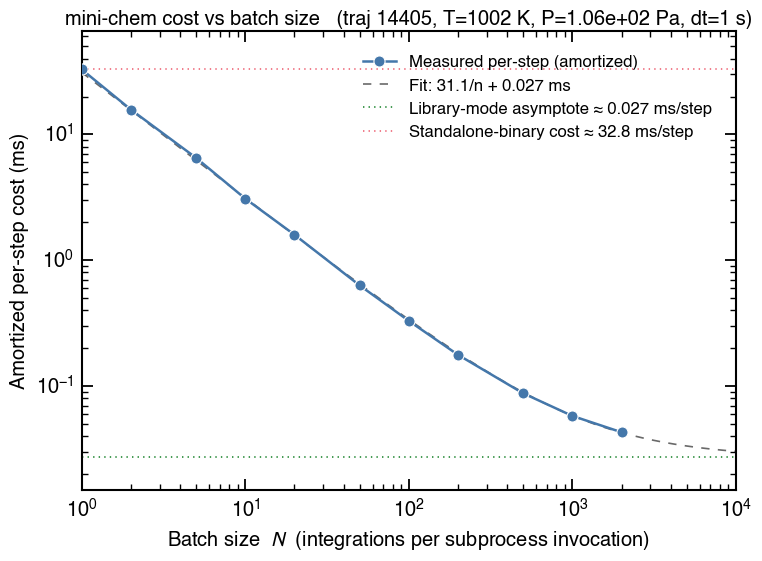

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)

# Measured per-step cost
ax.loglog(batch_arr, per_step_ms, "o-",
          color="#4477AA", lw=1.8, markersize=8,
          markeredgecolor="white", markeredgewidth=0.8,
          label="Measured per-step (amortized)", zorder=3)

# Model: per_step = overhead/n + chem_per_step
n_dense = np.logspace(np.log10(batch_arr.min()),
                      np.log10(batch_arr.max() * 5), 200)
model   = overhead_ms / n_dense + chem_per_step_ms
ax.loglog(n_dense, model, "--", color="0.35", lw=1.2, alpha=0.9,
          label=f"Fit: {overhead_ms:.1f}/n + {chem_per_step_ms:.3f} ms",
          zorder=2)

# Asymptote — what an embedded-library call would cost
ax.axhline(chem_per_step_ms, color="#228833", lw=1.2, ls=":",
           label=f"Library-mode asymptote ≈ {chem_per_step_ms:.3f} ms/step",
           zorder=1)

# Standalone-binary cost (n=1) — what we currently pay
ax.axhline(per_step_ms[0], color="#EE6677", lw=1.2, ls=":",
           label=f"Standalone-binary cost ≈ {per_step_ms[0]:.1f} ms/step",
           zorder=1)

ax.set_xlabel("Batch size  $N$  (integrations per subprocess invocation)")
ax.set_ylabel("Amortized per-step cost (ms)")
ax.set_title(
    f"mini-chem cost vs batch size   "
    f"(traj {_bti}, T={_T_K:.0f} K, P={_P_Pa:.2e} Pa, dt={_dt:g} s)"
)
ax.legend(loc="upper right", framealpha=0.9)
plt.show()

## Run on the VULCAN-Matched Grid (99 Steps)

Both surrogates step at `dt = t_vec[i] - t_vec[i-1]`. mini-chem dominates wall time
(subprocess per step).


In [9]:
results: dict[int, dict] = {}
overall_t0 = time.time()
for k, ti in enumerate(plot_idxs, 1):
    print(f"[{k}/{len(plot_idxs)}] traj {ti}  "
          f"P={P_Pa_all[ti]:.2e} Pa  T={g_mat[ti,1]:.0f} K")
    y_ar = predict_chemulator_autoregressive(ti)
    y_mc = run_minichem_trajectory(ti)
    results[ti] = {
        "truth": y_mat[ti].copy(),
        "ar":    y_ar,
        "mc":    y_mc,
    }
print(f"\nTotal: {time.time() - overall_t0:.1f} s")


[1/3] traj 14405  P=1.06e+02 Pa  T=1002 K
  emulator AR: stepping 99 times (dt range 2.95e-04 - 2.28e+07 s)
  emulator AR: completed 99 steps in 0.14 s
  mini-chem: stepping 99 times (dt range 2.95e-04 - 2.28e+07 s)
  mini-chem: completed 99 steps in 2.9 s
[2/3] traj 28961  P=1.54e+04 Pa  T=1869 K
  emulator AR: stepping 99 times (dt range 2.95e-04 - 2.28e+07 s)
  emulator AR: completed 99 steps in 0.13 s
  mini-chem: stepping 99 times (dt range 2.95e-04 - 2.28e+07 s)
  mini-chem: completed 99 steps in 2.9 s
[3/3] traj 32348  P=6.05e+06 Pa  T=2408 K
  emulator AR: stepping 99 times (dt range 2.95e-04 - 2.28e+07 s)
  emulator AR: completed 99 steps in 0.13 s
  mini-chem: stepping 99 times (dt range 2.95e-04 - 2.28e+07 s)
  mini-chem: completed 99 steps in 2.9 s

Total: 9.1 s


In [10]:
PLOT_SPECIES = ["CH4", "CO", "CO2", "H2O", "NH3", "HCN"]
PLOT_COLORS = {
    "CH4": "#EE6677", "CO":  "#4477AA", "CO2": "#228833",
    "H2O": "#AA3377", "NH3": "#66CCEE", "HCN": "#CCBB44",
}
SPECIES_LEGEND_LW = 1.5


def _species_legend_handles():
    return [
        Line2D([0], [0], color=PLOT_COLORS[sp], lw=SPECIES_LEGEND_LW, label=sp)
        for sp in PLOT_SPECIES
    ]


def _add_method_legend(ax, ar_label):
    method_handles = [
        Line2D([0], [0], color="k", lw=4.5, alpha=0.6, label="VULCAN (truth)"),
        Line2D([0], [0], color="k", lw=3.5, ls="--", label=ar_label),
        Line2D([0], [0], color="k", marker="o", linestyle="None", markersize=7,
               markeredgecolor="white", markeredgewidth=0.7,
               label="mini-chem (time-stepped)"),
    ]
    ax.legend(handles=method_handles, title="Method", loc="lower left")


def _add_species_legend(ax):
    ax.legend(handles=_species_legend_handles(), title="Species",
              ncol=2, loc="lower left",
              handlelength=1.5, handletextpad=0.5, columnspacing=1.0)

## Plot — VULCAN-Matched Grid (99 steps)

Solid = VULCAN truth, dashed = Chemulator autoregressive, markers = mini-chem time-stepped.


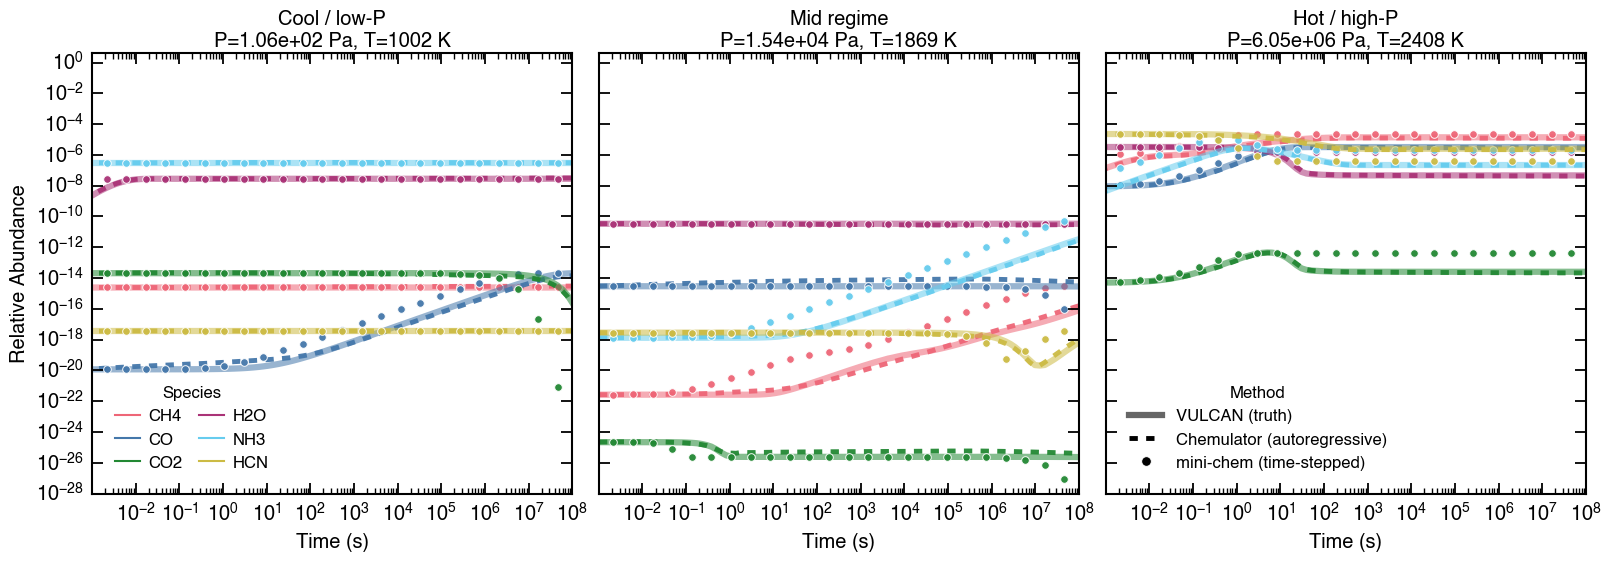

In [11]:
MC_MARKER_EVERY = 4   # 99-step grid: ~25 visible mini-chem markers


def plot_one(ax, traj_idx, label, t_pred, results_dict, mc_step):
    r          = results_dict[int(traj_idx)]
    y_true, y_ar, y_mc = r["truth"], r["ar"], r["mc"]
    g          = g_mat[int(traj_idx)]
    sp_indices = [NAMES.index(sp) for sp in PLOT_SPECIES]

    for sp_i, name in zip(sp_indices, PLOT_SPECIES):
        col = PLOT_COLORS[name]
        ax.loglog(t_vec,  np.clip(y_true[:, sp_i], TINY, None),
                  "-", color=col, lw=4.5, alpha=0.55)
        ax.loglog(t_pred, np.clip(y_ar[:, sp_i], TINY, None),
                  "--", color=col, lw=3.5, alpha=0.95)
        ax.loglog(t_pred[::mc_step], np.clip(y_mc[::mc_step, sp_i], TINY, None),
                  marker="o", linestyle="None", color=col, markersize=5.5,
                  markeredgecolor="white", markeredgewidth=0.7, alpha=0.95)

    ax.set_xlabel("Time (s)")
    ax.set_title(f"{label}\nP={P_Pa_all[int(traj_idx)]:.2e} Pa, T={g[1]:.0f} K")
    ax.set_ylim(1e-28, 4)


fig, axes = plt.subplots(1, 3, figsize=(16, 5.5),
                         sharey=True, constrained_layout=True)
for ax, ti, lbl in zip(axes, plot_idxs, plot_labels):
    plot_one(ax, ti, lbl, t_vec, results, MC_MARKER_EVERY)

axes[0].set_ylabel("Relative Abundance")
_add_species_legend(axes[0])
_add_method_legend(axes[-1], ar_label="Chemulator (autoregressive)")
plt.show()

## Dense Comparison — 1000 Steps to 1e8 s

Both surrogates step at a finer log-spaced grid than VULCAN's 99 intervals. The grid
starts at `t = 0.02 s` (so the first step has dt = 0.02 s — well above the trained
`DT_MIN`) and is log-spaced out to 1e8 s. Smallest interval ≈ 4.5e-4 s, ~1.5× DT_MIN —
no extrapolation. mini-chem requires 1000 subprocess calls per trajectory, so this
section is the slow one (~1–2 minutes).

**One difference from the 99-step run:** the autoregressive Chemulator output is
renormalized to `sum(species) = 1` after every step. This is a cheap projection back
onto the simplex manifold — the training data sums to ~1 by construction, and over 1000
steps the model's small per-step drift in total mass would otherwise pull the input
state off-manifold and trigger the inf/0 cascade described above. The 99-step run is
left untouched so its behavior matches the earlier comparison exactly.


In [12]:
N_INTERVALS_DENSE = 1000
T_MIN_DENSE       = 0.02      # >= DT_MIN; sets first dt and floor on log-spaced dt
T_MAX_DENSE       = 1e8

# 1001 points → 1000 intervals: t[0]=0 (IC), t[1..1000]=logspace(T_MIN, T_MAX)
t_grid_dense = np.concatenate([
    [0.0],
    np.logspace(np.log10(T_MIN_DENSE), np.log10(T_MAX_DENSE), N_INTERVALS_DENSE),
]).astype(np.float64)

_diffs = np.diff(t_grid_dense)
print(f"Dense grid: {len(t_grid_dense)} points, {len(t_grid_dense) - 1} intervals")
print(f"  dt range : [{_diffs.min():.3e}, {_diffs.max():.3e}] s")
print(f"  trained  : [{DT_MIN:.3e}, {DT_MAX:.3e}] s")
print(f"  ratio min/DT_MIN = {_diffs.min() / DT_MIN:.2f}x")
assert (_diffs >= DT_MIN * (1 - 1e-6)).all(), "dense grid violates DT_MIN"
assert (_diffs <= DT_MAX * (1 + 1e-6)).all(), "dense grid violates DT_MAX"


Dense grid: 1001 points, 1000 intervals
  dt range : [4.521e-04, 2.211e+06] s
  trained  : [2.949e-04, 1.000e+08] s
  ratio min/DT_MIN = 1.53x


In [13]:
results_dense: dict[int, dict] = {}
overall_t0 = time.time()
for k, ti in enumerate(plot_idxs, 1):
    print(f"[{k}/{len(plot_idxs)}] traj {ti}  "
          f"P={P_Pa_all[ti]:.2e} Pa  T={g_mat[ti,1]:.0f} K")
    y_ar = predict_chemulator_autoregressive_grid(
        ti, t_grid_dense, progress_every=200, renormalize=True,
    )
    y_mc = run_minichem_grid(ti, t_grid_dense, progress_every=200)
    results_dense[ti] = {
        "truth": y_mat[ti].copy(),   # VULCAN reference on its own t_vec grid
        "ar":    y_ar,                # on t_grid_dense
        "mc":    y_mc,                # on t_grid_dense
    }
print(f"\nTotal: {time.time() - overall_t0:.1f} s")


[1/3] traj 14405  P=1.06e+02 Pa  T=1002 K
  emulator AR: stepping 1000 times (dt range 4.52e-04 - 2.21e+06 s)
    [step 200/1000, elapsed 0.3s]
    [step 400/1000, elapsed 0.5s]
    [step 600/1000, elapsed 0.8s]
    [step 800/1000, elapsed 1.0s]
    [step 1000/1000, elapsed 1.3s]
  emulator AR: completed 1000 steps in 1.32 s  [renormalized; max |sum-1| seen = 1.38e-03]
  mini-chem: stepping 1000 times (dt range 4.52e-04 - 2.21e+06 s)
    [step 200/1000, elapsed 6.2s]
    [step 400/1000, elapsed 12.7s]
    [step 600/1000, elapsed 19.2s]
    [step 800/1000, elapsed 25.5s]
    [step 1000/1000, elapsed 31.5s]
  mini-chem: completed 1000 steps in 31.5 s
[2/3] traj 28961  P=1.54e+04 Pa  T=1869 K
  emulator AR: stepping 1000 times (dt range 4.52e-04 - 2.21e+06 s)
    [step 200/1000, elapsed 0.3s]
    [step 400/1000, elapsed 0.5s]
    [step 600/1000, elapsed 0.8s]
    [step 800/1000, elapsed 1.1s]
    [step 1000/1000, elapsed 1.4s]
  emulator AR: completed 1000 steps in 1.35 s  [renormalized; 

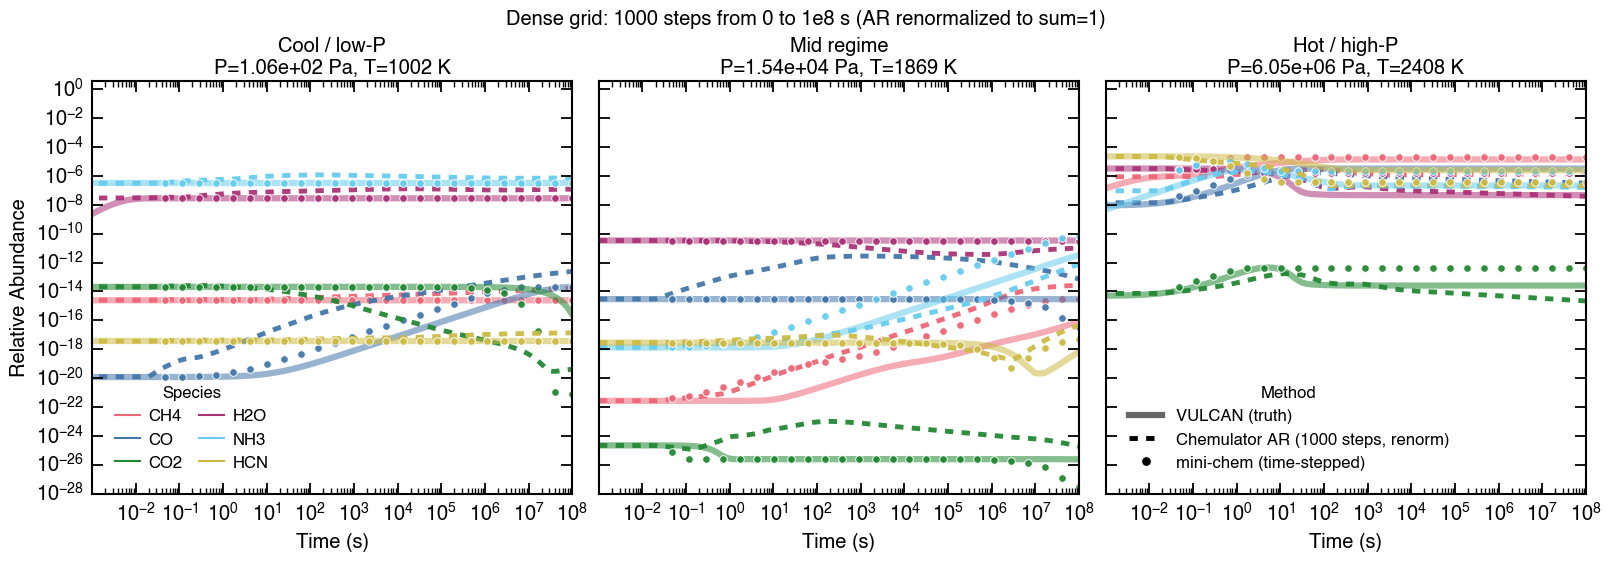

In [14]:
MC_MARKER_EVERY_DENSE = 40   # 1000-step grid: ~25 visible mini-chem markers

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5),
                         sharey=True, constrained_layout=True)
for ax, ti, lbl in zip(axes, plot_idxs, plot_labels):
    plot_one(ax, ti, lbl, t_grid_dense, results_dense, MC_MARKER_EVERY_DENSE)

axes[0].set_ylabel("Relative Abundance")
_add_species_legend(axes[0])
_add_method_legend(axes[-1], ar_label="Chemulator AR (1000 steps, renorm)")
fig.suptitle("Dense grid: 1000 steps from 0 to 1e8 s (AR renormalized to sum=1)")
plt.show()